### Step 1: 讀取圖片並轉換矩陣格式

彩色圖片維度 (m x n x 3): (4284, 5712, 3)
灰階圖片維度 (m x n): (4284, 5712)


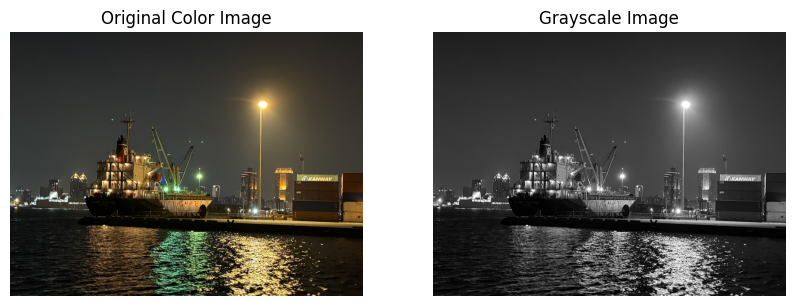

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. 讀取彩色圖片並轉為 Numpy 陣列
img_color = Image.open("my_image.jpg")
A_color = np.array(img_color)

# 2. 將圖片轉換為灰階並轉為 Numpy 陣列
img_gray = img_color.convert("L")
A_gray = np.array(img_gray)

# 顯示圖片維度資訊
print(f"彩色圖片維度 (m x n x 3): {A_color.shape}")
print(f"灰階圖片維度 (m x n): {A_gray.shape}")

# 顯示原圖與灰階圖
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(A_color)
ax[0].set_title("Original Color Image")
ax[0].axis('off')

ax[1].imshow(A_gray, cmap='gray')
ax[1].set_title("Grayscale Image")
ax[1].axis('off')

plt.show()

### Step 2: 奇異值分解 (Singular Value Decomposition) 與最佳逼近

在進行程式碼實作前，我們首先確立 SVD 的數學定義。對於任意影像矩陣 $A \in \mathbb{R}^{m \times n}$，我們可以將其進行奇異值分解：

$$A = U \Sigma V^T$$

其中：
* $U = [u_1, u_2, ..., u_m]$ 是一個 $m \times m$ 的正交矩陣 (Orthogonal Matrix)，其行向量稱為左奇異向量 (Left Singular Vectors)。
* $\Sigma = \text{diag}[\sigma_1, \sigma_2, ..., \sigma_p]$ 是一個 $m \times n$ 的對角矩陣，對角線上的元素 $\sigma_i$ 即為奇異值 (Singular Values)，且依降序排列。這裡的 $p = \min\{m, n\}$。
* $V = [v_1, v_2, ..., v_n]$ 是一個 $n \times n$ 的正交矩陣，其行向量稱為右奇異向量 (Right Singular Vectors)。

**降維與影像壓縮 (Rank-$k$ Approximation)**

為了達到壓縮圖片的目的，我們選取前 $k$ 個最重要的奇異值 ($0 < k < p$)，來建構一個新的矩陣 $A_k$。這可以表示為前 $k$ 個 Rank-1 矩陣的線性組合：

$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

**Eckart-Young-Mirsky 定理 (誤差估計)**

根據最佳逼近理論，在所有秩為 $k$ 的矩陣中，$A_k$ 是在 2-norm 意義下最接近原矩陣 $A$ 的解。其捨棄掉的資訊量（即截斷誤差）精準地等於第 $k+1$ 個奇異值：

$$||A - A_k||_2 = \sigma_{k+1}$$

我們接下來將透過 Python 實作來驗證此數學定理。

---

In [2]:
def svd_restore(image, k):
    """
    對圖片矩陣進行 SVD 分解，並保留前 k 個奇異值進行重建。
    """
    # 1. 執行 SVD 分解 (full_matrices=False 表示使用精簡版 SVD，加快運算並節省記憶體)
    u, sigma, vt = np.linalg.svd(image, full_matrices=False)
    
    # 2. 避免 k 值超出奇異值的數量上限
    k = min(len(sigma) - 1, k)
    
    # 3. 依照 k 值，擷取前 k 個特徵並重建新的圖形矩陣 Ak
    # 這裡對應數學式：Ak = U_k * Sigma_k * V^T_k
    Ak = np.dot(u[:, :k], np.dot(np.diag(sigma[:k]), vt[:k, :]))
    
    # 4. 處理溢位問題：數學運算後可能會有微小誤差導致數值超出 0~255 的範圍
    Ak[Ak < 0] = 0
    Ak[Ak > 255] = 255
    
    # 5. 將浮點數四捨五入，並轉型為圖片所需的 uint8 格式
    Ak = np.rint(Ak).astype('uint8')
    
    # 我們順便回傳完整的 sigma 陣列，這對驗證 Step 3 非常重要！
    return Ak, sigma

#### 2-norm

In [3]:
def calculate_2norm(A, Ak):
    """
    計算原圖矩陣 A 與壓縮圖矩陣 Ak 之間的 2-norm 誤差 (||A - Ak||_2)
    """
    return np.linalg.norm(A - Ak, 2)

### Step 3: 驗證最佳逼近理論 (Error Estimate)

根據理論，我們知道截斷前 $k$ 個奇異值所造成的 2-norm 誤差，會剛好等於第 $k+1$ 個奇異值。

為了驗證此事，我們將設定一組不同的 $k$ 值陣列（例如 $k = 1, 5, 10, 20...$ 等），針對我們的「灰階圖片矩陣」進行 SVD 分解與重建，並計算出實際的 $||A - A_k||_2$ 數值，與理論的 $\sigma_{k+1}$ 進行嚴格比對。

> **注意**：為了驗證純數學的等式，我們在計算 2-norm 誤差時，不對矩陣進行 `uint8` 的轉型與四捨五入（即不截斷小數點），以保留浮點數的精確度。

In [4]:
import pandas as pd

# 定義要測試的 k 值範圍
k_values = [1, 5, 10, 15, 20, 30, 50, 80, 100, 150, 200, 300, 500]

# 準備一個列表來儲存驗證結果
validation_results = []

# 為了驗證純數學，我們對原本的灰階矩陣做一次完整的 SVD，並強制轉為 float64 確保精度
A_float = A_gray.astype(np.float64)
U, Sigma, VT = np.linalg.svd(A_float, full_matrices=False)

for k in k_values:
    # 確保 k 不會超出 Sigma 的數量
    if k >= len(Sigma):
        break
        
    # 1. 產生純數學上的近似矩陣 Ak (不轉 uint8，不限制 0~255)
    Ak_math = np.dot(U[:, :k], np.dot(np.diag(Sigma[:k]), VT[:k, :]))
    
    # 2. 計算實際的 2-norm 誤差: ||A - Ak||_2
    error_2norm = calculate_2norm(A_float, Ak_math)
    
    # 3. 取得理論上的誤差: 第 k+1 個奇異值 (在 Python 陣列中索引為 k)
    sigma_k_plus_1 = Sigma[k]
    
    # 將結果記錄下來
    validation_results.append({
        "K 值": k,
        "2-norm 誤差 (||A - Ak||_2)": error_2norm,
        "Sigma_{k+1}": sigma_k_plus_1,
        "是否相等 (誤差<1e-8)": abs(error_2norm - sigma_k_plus_1) < 1e-8
    })

# 轉換成 DataFrame 並顯示，排版會非常精美
df_validation = pd.DataFrame(validation_results)
display(df_validation)

,K 值,2-norm 誤差 (||A - Ak||_2),Sigma_{k+1},是否相等 (誤差<1e-8)
0,1,79424.067571,79424.067571,True
1,5,31805.778754,31805.778754,True
2,10,23433.441012,23433.441012,True
3,15,19155.022132,19155.022132,True
4,20,16469.706196,16469.706196,True
5,30,13760.848381,13760.848381,True
6,50,10171.634130,10171.634130,True
7,80,7345.392036,7345.392036,True
8,100,6086.123901,6086.123901,True
9,150,4245.491586,4245.491586,True


### Step 4: 尋找最佳的 $k$ 值 (Compression Ratio vs. Image Quality)

為了客觀評估壓縮效果，我們引入以下四個指標：

1. **資料壓縮比 (Compression Ratio, CR)**：
   原圖的儲存量為 $m \times n$。SVD 壓縮後，我們只需儲存 $k$ 個奇異值、以及 $U$ 和 $V^T$ 的前 $k$ 個向量，儲存量為 $k \times (1 + m + n)$。
   $$CR = \frac{m \times n}{k(1 + m + n)}$$

2. **節省空間比率 (Save Space, SS)**：
   評估節省了多少百分比的空間。
   $$SS = \left(1 - \frac{1}{CR}\right) \times 100\%$$

3. **均方誤差 (Mean Squared Error, MSE)**：
   衡量原圖 $A$ 與壓縮圖 $A_k$ 每個像素差異的平方平均。
   $$MSE = \frac{1}{m \times n} \sum_{i=1}^{m} \sum_{j=1}^{n} (A_{i,j} - (A_k)_{i,j})^2$$

4. **峰值訊噪比 (Peak Signal-to-Noise Ratio, PSNR)**：
   用對數尺度來衡量影像失真程度，單位為 dB。值越高代表畫質越好。
   $$PSNR = 10 \cdot \log_{10}\left(\frac{255^2}{MSE}\right)$$

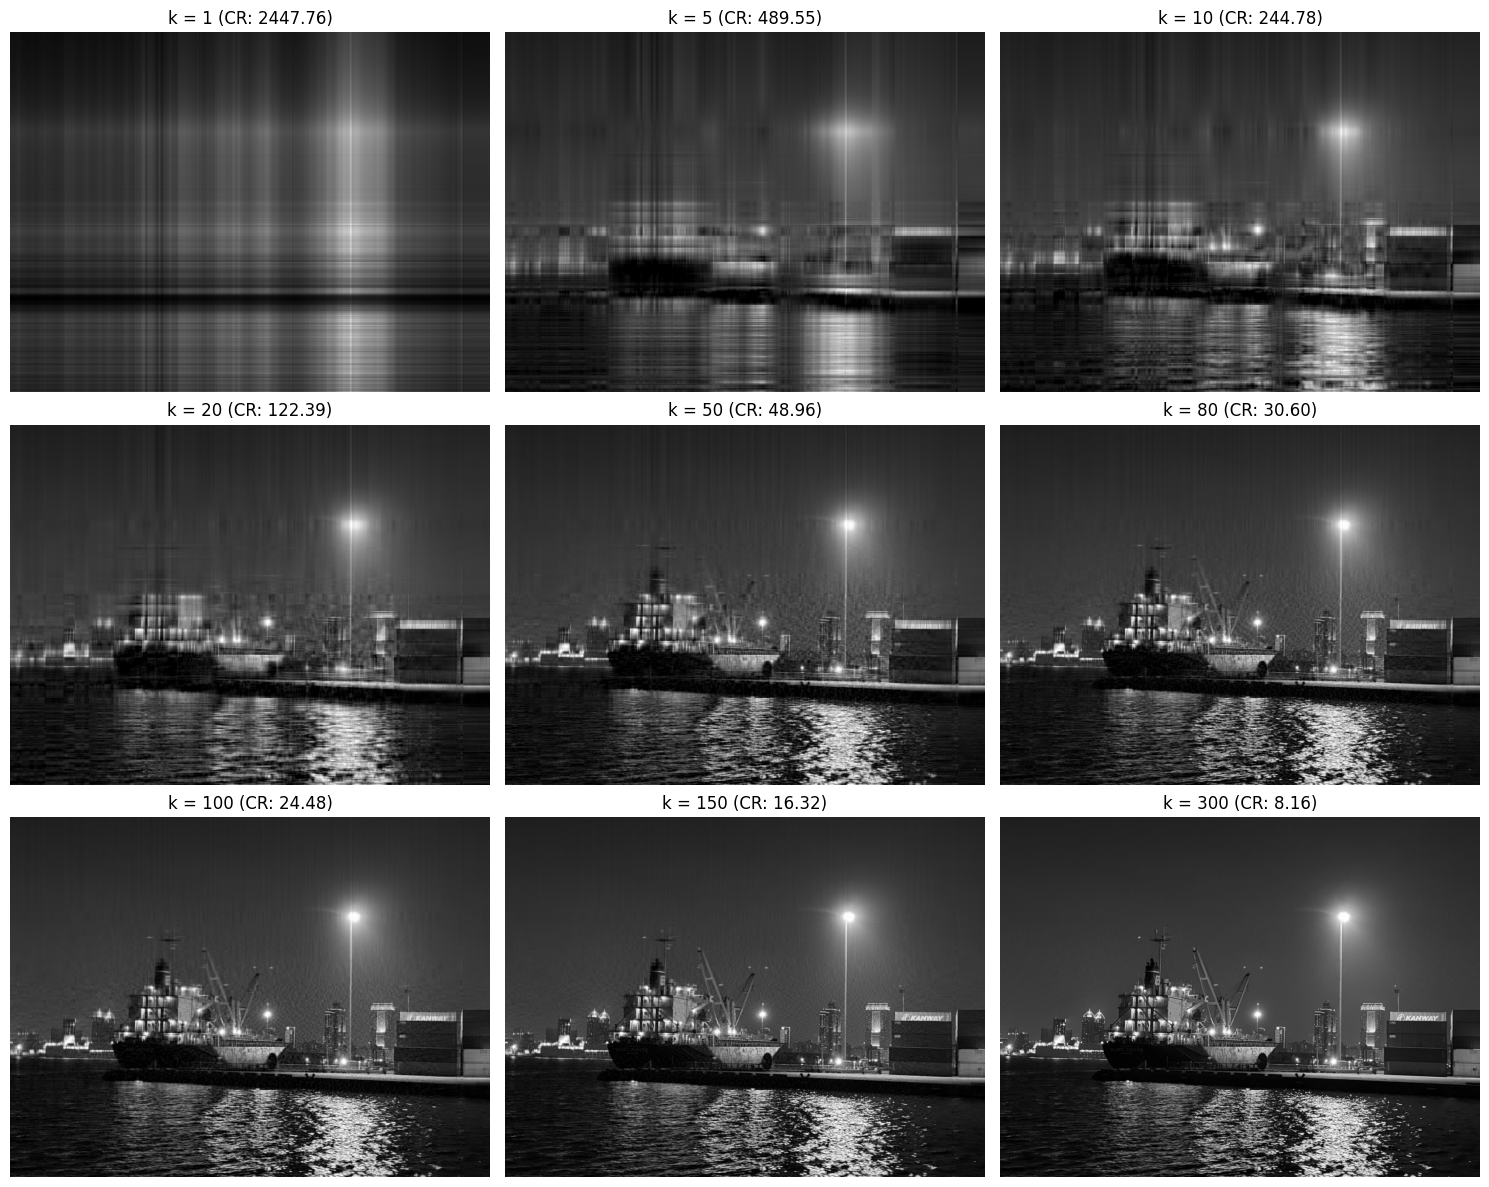

,K 值,資料壓縮比 (CR),節省空間比率 (SS) %,均方誤差 (MSE),峰值訊噪比 (PSNR)
0,1,2447.7551,99.96,1337.37,16.87
1,5,489.5510,99.80,774.61,19.24
2,10,244.7755,99.59,616.47,20.23
3,20,122.3878,99.18,456.36,21.54
4,50,48.9551,97.96,246.32,24.22
5,80,30.5969,96.73,153.59,26.27
6,100,24.4776,95.91,116.85,27.45
7,150,16.3184,93.87,63.52,30.10
8,300,8.1592,87.74,13.96,36.68


In [5]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 定義評估指標函數 ---
def calculate_mse(original, compressed):
    # 計算 MSE (需轉為 float 避免 uint8 溢位) [cite: 194]
    return np.mean((original.astype(float) - compressed.astype(float)) ** 2)

def calculate_psnr(original, compressed):
    mse = calculate_mse(original, compressed)
    if mse == 0:
        return 100 # 如果完全相同，回傳一個極大值 [cite: 198, 199, 200]
    return 10 * math.log10((255.0 ** 2) / mse) # [cite: 201]

def calculate_size_kb(m, n, k=None):
    # 假設每個像素值佔 1 byte，計算圖片大小 (KB)
    if k is None:
        return (m * n) / 1024 # 原圖大小
    else:
        return (k * (1 + m + n)) / 1024 # 壓縮後大小

# --- 2. 準備畫圖與計算結果 ---
m, n = A_gray.shape
original_size = calculate_size_kb(m, n)

# 學長使用的 k 值範圍 [cite: 213]
k_values = [1, 5, 10, 20, 50, 80, 100, 150, 300] 
metrics = []

# 設定畫布 (3x3 的九宮格)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    # 呼叫 Step 2 寫好的函數，取得壓縮後的圖片 Ak
    Ak, _ = svd_restore(A_gray, k)
    
    # 計算各項指標
    comp_size = calculate_size_kb(m, n, k)
    cr = original_size / comp_size
    ss = (1 - comp_size / original_size) * 100
    mse = calculate_mse(A_gray, Ak)
    psnr = calculate_psnr(A_gray, Ak)
    
    # 存入表格資料
    metrics.append({
        "K 值": k,
        "資料壓縮比 (CR)": f"{cr:.4f}",
        "節省空間比率 (SS) %": f"{ss:.2f}",
        "均方誤差 (MSE)": f"{mse:.2f}",
        "峰值訊噪比 (PSNR)": f"{psnr:.2f}"
    })
    
    # 將圖片畫到子圖上 
    axes[idx].imshow(Ak, cmap='gray')
    axes[idx].set_title(f"k = {k} (CR: {cr:.2f})")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# --- 3. 顯示統整表格 ---
df_metrics = pd.DataFrame(metrics)
display(df_metrics)

### Step 5: 趨勢折線圖分析 (尋找最佳 $k$ 值)

為了直觀地找出畫質與壓縮率的最佳平衡點，我們將剛才計算出的四個指標對應 $k$ 值畫成折線圖：

1. **負相關指標 (SS, MSE)**：隨著 $k$ 值增加，節省空間比率 (SS) 會急遽下降（因為需要儲存更多矩陣資料），均方誤差 (MSE) 也會快速下降（因為畫質越來越接近原圖）。
2. **正相關指標 (SIZE, PSNR)**：隨著 $k$ 值增加，壓縮後的檔案大小 (SIZE) 會線性上升，而峰值訊噪比 (PSNR) 也會跟著上升（畫質變好）。

**尋找 Elbow Point (轉折點)**：
從折線圖中我們可以觀察到，當 $k$ 值超過某個臨界點（例如 $k=50 \sim 100$ 之間）後，PSNR 的上升幅度變得非常平緩（這稱為邊際效益遞減），但檔案大小卻仍持續增加。因此，這個「轉折點」就是我們心目中最佳的 $k$ 值！

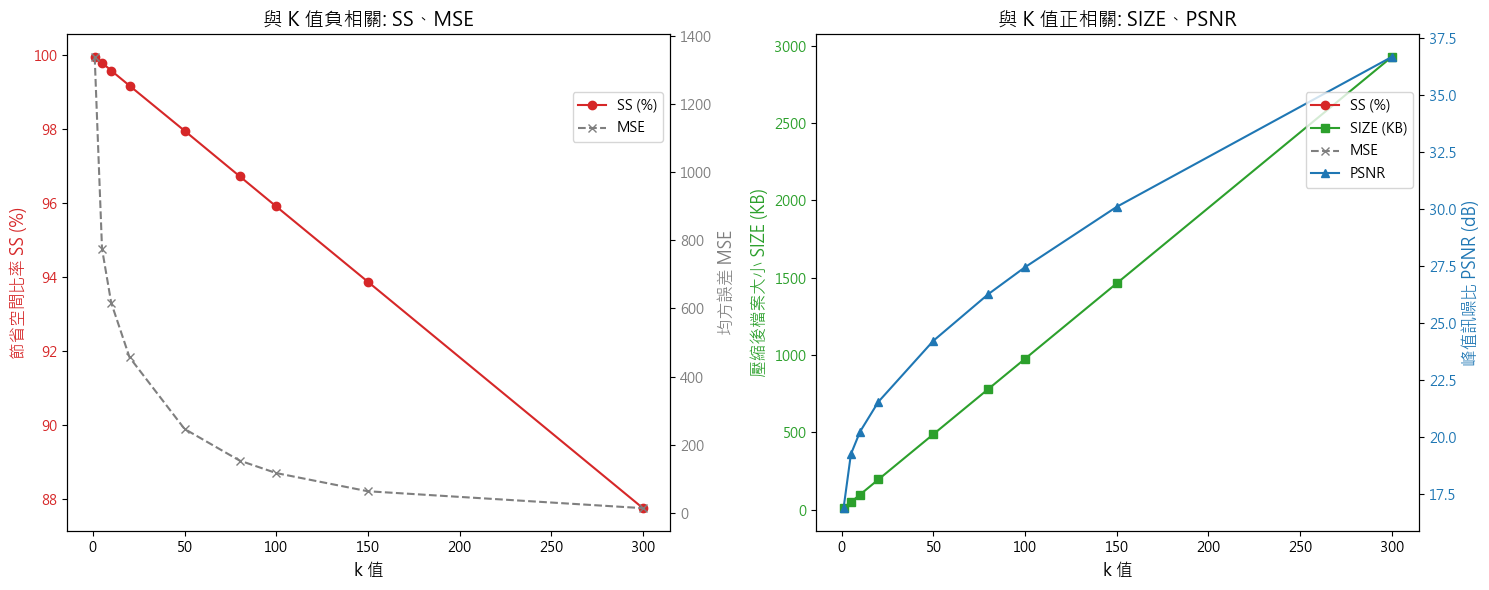

In [7]:
import matplotlib.pyplot as plt

# --- 新增這兩行來解決中文顯示問題 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 設定字體為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 解決座標軸負號顯示問題

# 將字串轉回數值以便畫圖
k_vals = df_metrics["K 值"].astype(int)
ss_vals = df_metrics["節省空間比率 (SS) %"].astype(float)
mse_vals = df_metrics["均方誤差 (MSE)"].astype(float)
psnr_vals = df_metrics["峰值訊噪比 (PSNR)"].astype(float)
# 重新計算 Size 方便畫圖
size_vals = [calculate_size_kb(m, n, k) for k in k_vals]

# 設定畫布，左右兩張圖
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(15, 6))

# --- 第一張圖：與 K 值負相關 (SS, MSE) ---
color1 = 'tab:red'
ax1.set_xlabel('k 值', fontsize=12)
ax1.set_ylabel('節省空間比率 SS (%)', color=color1, fontsize=12)
ax1.plot(k_vals, ss_vals, color=color1, marker='o', label='SS (%)')
ax1.tick_params(axis='y', labelcolor=color1)

# 共用 X 軸，建立第二個 Y 軸畫 MSE
ax2 = ax1.twinx()  
color2 = 'tab:gray'
ax2.set_ylabel('均方誤差 MSE', color=color2, fontsize=12)
ax2.plot(k_vals, mse_vals, color=color2, marker='x', linestyle='--', label='MSE')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('與 K 值負相關: SS、MSE', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.45, 0.85))

# --- 第二張圖：與 K 值正相關 (SIZE, PSNR) ---
color3 = 'tab:green'
ax3.set_xlabel('k 值', fontsize=12)
ax3.set_ylabel('壓縮後檔案大小 SIZE (KB)', color=color3, fontsize=12)
ax3.plot(k_vals, size_vals, color=color3, marker='s', label='SIZE (KB)')
ax3.tick_params(axis='y', labelcolor=color3)

# 共用 X 軸，建立第二個 Y 軸畫 PSNR
ax4 = ax3.twinx()  
color4 = 'tab:blue'
ax4.set_ylabel('峰值訊噪比 PSNR (dB)', color=color4, fontsize=12)
ax4.plot(k_vals, psnr_vals, color=color4, marker='^', linestyle='-', label='PSNR')
ax4.tick_params(axis='y', labelcolor=color4)

ax3.set_title('與 K 值正相關: SIZE、PSNR', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
plt.show()

### Step 6: 彩色圖片 (RGB) 的 SVD 壓縮

彩色圖片是一個 $m \times n \times 3$ 的三維張量 (Tensor)，包含了 R (紅)、G (綠)、B (藍) 三個通道。因為傳統的 SVD 只能處理二維矩陣，我們有兩種常見的策略來進行壓縮：

**方法一：Reshape Method (改變形狀法)**
* **概念**：直接把三維張量「壓扁」成二維矩陣。我們將原本 $m \times n \times 3$ 的形狀，變形 (Reshape) 成 $m \times (n \times 3)$ 的寬矩陣。對這個大矩陣做完 SVD 壓縮後，再把它還原回三維的形狀。
* **優點**：只做一次 SVD，速度可能較快。

**方法二：Layers Method (分層處理法)**
* **概念**：把彩色圖片當作三張獨立的灰階圖片。我們把 R、G、B 三個通道拆開，分別對它們做獨立的 SVD 分解與壓縮。三個通道都壓縮好之後，再把它們像漢堡一樣疊起來 (Stack)。
* **優點**：保留了各個顏色通道的獨立特徵，通常還原出來的顏色過渡比較自然。本作業我們重點展示這個方法。

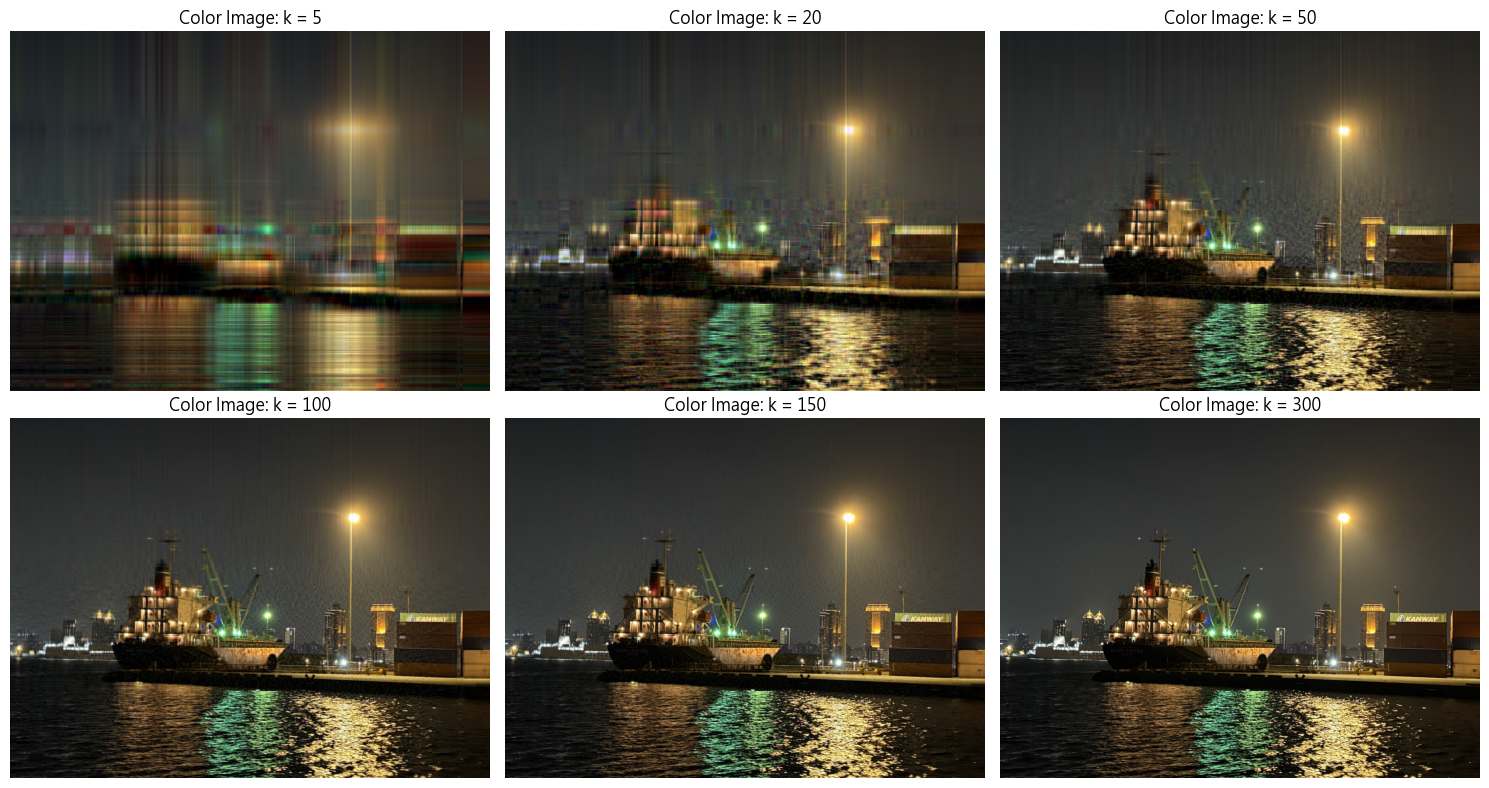

In [8]:
# --- 實作彩色圖片壓縮 (Layers Method) ---
import numpy as np
import matplotlib.pyplot as plt

# 設定我們想要觀察的 k 值
k_values_color = [5, 20, 50, 100, 150, 300]

# 設定畫布 (2x3 的六宮格)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# 針對每一個 k 值進行彩色壓縮
for idx, k in enumerate(k_values_color):
    
    # 1. 將 R, G, B 三個通道拆開，並分別丟進我們先前寫好的 svd_restore 函數
    # A_color[:, :, 0] 是 R 通道，[:, :, 1] 是 G 通道，[:, :, 2] 是 B 通道
    R_comp, _ = svd_restore(A_color[:, :, 0], k)
    G_comp, _ = svd_restore(A_color[:, :, 1], k)
    B_comp, _ = svd_restore(A_color[:, :, 2], k)
    
    # 2. 將壓縮後的 R, G, B 三個二維矩陣重新疊合 (Stack) 成三維張量
    Ak_color = np.dstack((R_comp, G_comp, B_comp))
    
    # 3. 畫出壓縮後的彩色圖片
    axes[idx].imshow(Ak_color)
    axes[idx].set_title(f"Color Image: k = {k}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()